In [42]:
from sklearn.datasets import make_swiss_roll
from phate import PHATE
from uphate import get_phate_embedding
import matplotlib.pyplot as plt
import jax.numpy as jnp
import jax
from scipy.spatial.transform import Rotation

# Testing on a basic Swiss Roll dataset

In [55]:
X, color = make_swiss_roll(n_samples=300)

# PHATE params
n_components = 2
knn = 5
decay = 40
t = 25

In [56]:
phate_op = PHATE(
    n_components=n_components,
    knn=knn,
    decay=decay,
    t=t,
    n_landmark=None,
    mds_solver="smacof",
)

X_phate = phate_op.fit_transform(X)

Calculating PHATE...
  Running PHATE on 300 observations and 3 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculating affinities...
  Calculating diffusion potential...
  Calculated diffusion potential in 0.10 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 0.11 seconds.
Calculated PHATE in 0.27 seconds.


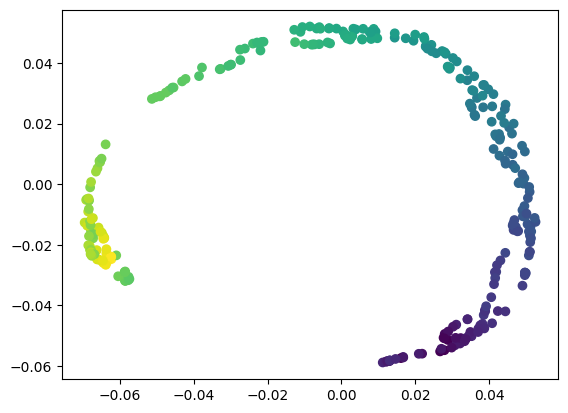

In [57]:
plt.scatter(*X_phate.T, c=color)

In [58]:
X_uphate = get_phate_embedding(
    jnp.array(X),
    key=jax.random.PRNGKey(0),
    n_components=n_components,
    knn=knn,
    decay=decay,
    t=t,
)

X_phate_3d = jnp.concatenate([X_phate, jnp.zeros((X_phate.shape[0], 1))], axis=1)
X_uphate_3d = jnp.concatenate([X_uphate, jnp.zeros((X_uphate.shape[0], 1))], axis=1)
rotation, _ = Rotation.align_vectors(X_phate_3d, X_uphate_3d)

X_uphate = rotation.apply(X_uphate_3d)[:, :2]

We see that PHATE vs. uPHATE gives very similar embeddings

Text(0.5, 1.0, 'PHATE')

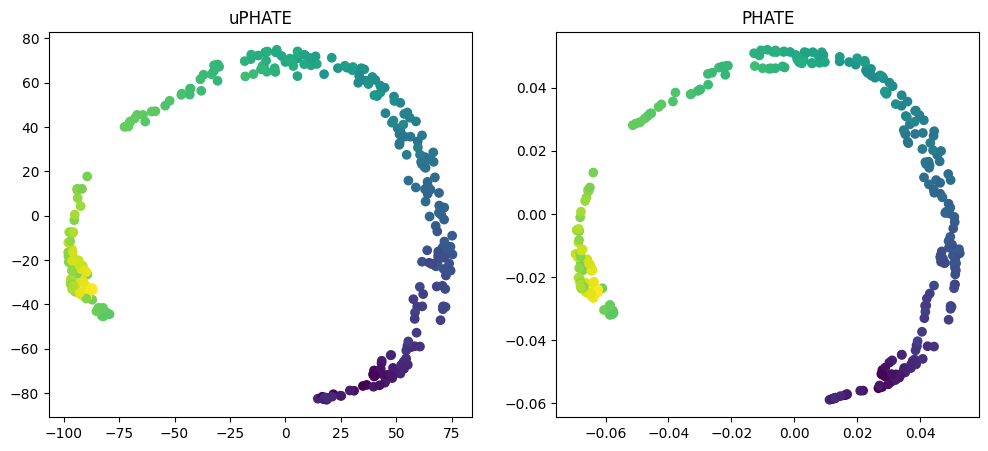

In [59]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(*X_uphate.T, c=color)
ax[0].set_title("uPHATE")

ax[1].scatter(*X_phate.T, c=color)
ax[1].set_title("PHATE")